# rBergomi 定价复刻（Bayer et al., 2015）

目标：在现有 `MUZ -> H/nu -> RFSV` 工作基础上，新增期权截面定价复刻，并对比：

1. 固定 `H` vs 放开 `H`
2. `eta` 初值来自 `sqrt(nu_sq)` vs 随机初值
3. 期权截面误差（IV RMSE / ATM term / skew）与时间序列 `P-ratio` 并行展示

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../models')

from DataFetcher import DataFetcher
from HurstEstimator import HurstEstimator
from RFSVPredictor import estimate_nu_sq, RFSVPredictor, predict_ar, predict_har, compute_p_ratio
from rBergomiPricer import rBergomiPricer
from rBergomiCalibrator import rBergomiCalibrator

pd.set_option('display.max_columns', 100)
np.random.seed(42)

In [2]:
# 1) 从已有方差代理数据估计 H 与 nu_sq，作为 rBergomi 初值来源
variance_path = '../data/variance_proxy_20200101_20251231.csv'
df_var = pd.read_csv(variance_path)
df_var['date'] = pd.to_datetime(df_var['date'])
df_var = df_var.sort_values('date').reset_index(drop=True)

log_var = np.log(df_var['rv_uz'].values)
log_sigma = 0.5 * pd.Series(log_var)

hurst_estimator = HurstEstimator()
H_hist, h_info = hurst_estimator.estimate_hurst_variogram(log_sigma, q=2.0)
nu_sq_hist, nu_info = estimate_nu_sq(log_var, delta_max=120)
eta_hist = float(np.sqrt(max(nu_sq_hist, 1e-10)))

print(f'H (historical) = {H_hist:.4f}, R2 = {h_info.get("r_squared", np.nan):.4f}')
print(f'nu_sq (historical) = {nu_sq_hist:.6f}, eta0 = sqrt(nu_sq) = {eta_hist:.6f}')

H (historical) = 0.1064, R2 = 0.9308
nu_sq (historical) = 0.038506, eta0 = sqrt(nu_sq) = 0.196231


In [3]:
# 2) 构建期权截面数据（同时拉取米筐API iv）
UNDERLYING = '000300.XSHG'
TRADE_DATE = '20250110'  # 可改为任意交易日

license_key = os.environ.get('RQDATAC_LICENSE')
fetcher = DataFetcher(license=license_key)
fetcher.init_connection()

cross = fetcher.build_option_cross_section(
    underlying_symbol=UNDERLYING,
    trade_date=TRADE_DATE,
    risk_free_rate=0.02,
    dividend_yield=0.0,
    min_days_to_expiry=7,
    min_price=1e-4,
    min_volume=0.0,
    use_mid_price=True,
    include_api_iv=True,
    greeks_model='implied_forward',
    greeks_price_type='close'
)

print('cross-section size:', len(cross))
if 'api_iv' in cross.columns:
    print('api_iv missing ratio:', cross['api_iv'].isna().mean())

cross.head()

✓ 米筐数据连接成功
cross-section size: 264
api_iv missing ratio: 0.0


,trade_date,order_book_id,S0,r,q,maturity,strike,option_type,market_price,volume,days_to_expiry,api_iv
0,2025-01-10,IO2501C3350,3732.4806,0.02,0.0,0.019178,3350.0,call,418.5,22.0,7,0.776234
1,2025-01-10,IO2501P3350,3732.4806,0.02,0.0,0.019178,3350.0,put,0.6,98.0,7,0.339405
2,2025-01-10,IO2501C3400,3732.4806,0.02,0.0,0.019178,3400.0,call,367.2,11.0,7,0.682201
3,2025-01-10,IO2501P3400,3732.4806,0.02,0.0,0.019178,3400.0,put,0.5,103.0,7,0.298407
4,2025-01-10,IO2501C3450,3732.4806,0.02,0.0,0.019178,3450.0,call,310.9,27.0,7,0.498123


In [4]:
# 3) rBergomi 校准（两组核心比较）
pricer = rBergomiPricer(n_steps_per_year=252, n_paths=2500, seed=2026)
calibrator = rBergomiCalibrator(pricer=pricer, random_seed=2026)

xi0 = float(np.exp(np.mean(log_var[-60:])))  # 先用近 60 日方差均值作平坦 xi0

# A: 固定 H，eta 初值来自 sqrt(nu_sq)
res_fix_nu = calibrator.calibrate(
    option_df=cross,
    H_init=H_hist,
    eta_init=eta_hist,
    rho_init=-0.7,
    xi=xi0,
    fix_H=True,
    skew_penalty=0.2,
    maxiter=30
)

# B: 固定 H，eta 随机初值（用于比较初值敏感性）
res_fix_rand = calibrator.calibrate(
    option_df=cross,
    H_init=H_hist,
    eta_init=0.8,
    rho_init=-0.7,
    xi=xi0,
    fix_H=True,
    skew_penalty=0.2,
    maxiter=30
)

# C: 放开 H
res_free_h = calibrator.calibrate(
    option_df=cross,
    H_init=H_hist,
    eta_init=eta_hist,
    rho_init=-0.7,
    xi=xi0,
    fix_H=False,
    skew_penalty=0.2,
    maxiter=30
)

res_fix_nu['best_params'], res_fix_rand['best_params'], res_free_h['best_params']

({'H': 0.10639954801300495,
  'eta': 1.999439836786166,
  'rho': -0.940718837258647},
 {'H': 0.10639954801300495,
  'eta': 1.8142736642085664,
  'rho': -0.9634425474533638},
 {'H': 0.02, 'eta': 1.216739377829599, 'rho': -0.999})

In [5]:
# 4) 期权截面指标汇总
def flatten_metrics(tag, result):
    d = {'scenario': tag}
    d.update(result['best_params'])
    d.update(result['metrics'])
    d['opt_success'] = result['optimizer']['success']
    d['opt_iter'] = result['optimizer']['n_iter']
    return d

df_option_metrics = pd.DataFrame([
    flatten_metrics('fix_H_eta_from_nu', res_fix_nu),
    flatten_metrics('fix_H_eta_random', res_fix_rand),
    flatten_metrics('free_H_eta_from_nu', res_free_h),
]).sort_values('iv_rmse')

df_option_metrics

,scenario,H,eta,rho,iv_rmse,iv_mae,price_rmse,atm_term_error,skew_error,opt_success,opt_iter
2,free_H_eta_from_nu,0.0200,1.216739,-0.999000,0.180685,0.143582,101.814640,0.179495,0.887668,True,8
0,fix_H_eta_from_nu,0.1064,1.999440,-0.940719,0.187792,0.154249,100.541607,0.178948,1.023080,True,16
1,fix_H_eta_random,0.1064,1.814274,-0.963443,0.187984,0.154079,100.564944,0.179022,1.022332,True,12


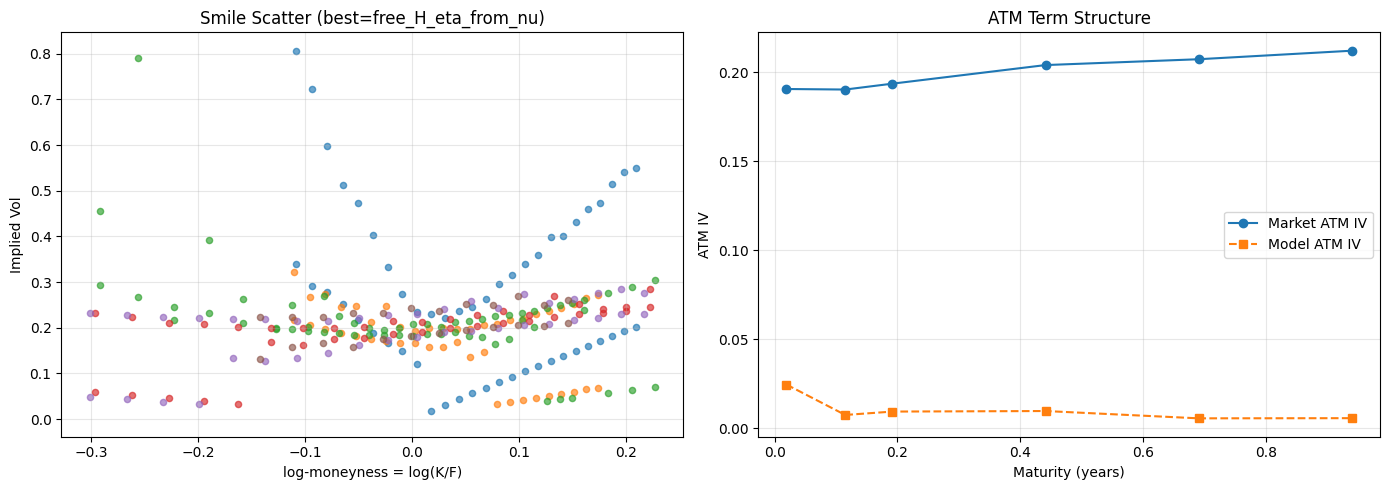

In [6]:
# 5) Smile 与 Term/Skew 可视化（使用最优场景）
best_tag = df_option_metrics.iloc[0]['scenario']
best_map = {
    'fix_H_eta_from_nu': res_fix_nu,
    'fix_H_eta_random': res_fix_rand,
    'free_H_eta_from_nu': res_free_h,
}
best_res = best_map[best_tag]
best_df = best_res['priced_df'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# smile
for T, sub in best_df.groupby('maturity'):
    if len(sub) < 5:
        continue
    sub = sub.copy()
    F = sub['S0'].iloc[0] * np.exp((sub['r'].iloc[0] - sub['q'].iloc[0]) * T)
    sub['log_mny'] = np.log(sub['strike'] / F)
    # market: filled circle
    axes[0].scatter(
        sub['log_mny'], sub['market_iv'],
        s=20, alpha=0.65, marker='o',
        label=f'MKT T={T:.3f}'
    )
    # model: hollow triangle
    axes[0].scatter(
        sub['log_mny'], sub['model_iv'],
        s=28, alpha=0.9, marker='^',
        facecolors='none', linewidths=1.1,
        label=f'MDL T={T:.3f}'
    )
axes[0].set_title(f'Smile Scatter (best={best_tag})')
axes[0].set_xlabel('log-moneyness = log(K/F)')
axes[0].set_ylabel('Implied Vol')
axes[0].grid(alpha=0.3)

# ATM term
atm_rows = []
for T, sub in best_df.groupby('maturity'):
    sub = sub.copy()
    F = sub['S0'].iloc[0] * np.exp((sub['r'].iloc[0] - sub['q'].iloc[0]) * T)
    sub['abs_mny'] = np.abs(np.log(sub['strike'] / F))
    atm = sub.nsmallest(max(2, len(sub)//6), 'abs_mny')
    atm_rows.append({
        'maturity': T,
        'market_atm_iv': atm['market_iv'].mean(),
        'model_atm_iv': atm['model_iv'].mean(),
    })

df_atm = pd.DataFrame(atm_rows).sort_values('maturity')
axes[1].plot(df_atm['maturity'], df_atm['market_atm_iv'], 'o-', label='Market ATM IV')
axes[1].plot(df_atm['maturity'], df_atm['model_atm_iv'], 's--', label='Model ATM IV')
axes[1].set_title('ATM Term Structure')
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('ATM IV')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
cols_to_check = [c for c in ['api_iv', 'market_iv', 'model_iv'] if c in best_df.columns]
print(best_df[cols_to_check].isna().mean())

chk = (
    best_df.groupby('maturity')[cols_to_check]
    .apply(lambda x: pd.Series({
        'n_total': len(x),
        'n_api_valid': x['api_iv'].notna().sum() if 'api_iv' in x.columns else np.nan,
        'n_market_valid': x['market_iv'].notna().sum() if 'market_iv' in x.columns else np.nan,
        'n_model_valid': x['model_iv'].notna().sum() if 'model_iv' in x.columns else np.nan,
    }))
    .reset_index()
)
display(chk)

api_iv       0.000000
market_iv    0.000000
model_iv     0.484848
dtype: float64


,maturity,n_total,n_api_valid,n_market_valid,n_model_valid
0,0.019178,52,52,52,26
1,0.115068,46,46,46,24
2,0.191781,62,62,62,32
3,0.441096,40,40,40,20
4,0.690411,40,40,40,21
5,0.939726,24,24,24,13


In [8]:
# 1) 看是不是某个 option_type 整体失败（含 api/local/model 三方）
base_cols = ['market_iv', 'model_iv'] + (['api_iv'] if 'api_iv' in best_df.columns else [])

display(
    best_df.groupby('option_type')[base_cols]
    .apply(lambda x: pd.Series({
        'n': len(x),
        'api_iv_valid_ratio': x['api_iv'].notna().mean() if 'api_iv' in x.columns else np.nan,
        'local_market_iv_valid_ratio': x['market_iv'].notna().mean(),
        'model_iv_valid_ratio': x['model_iv'].notna().mean(),
    }))
)

# 2) 分 maturity + option_type 看更细
detail_rows = []
for (T, ot), sub in best_df.groupby(['maturity', 'option_type']):
    detail_rows.append({
        'maturity': T,
        'option_type': ot,
        'n': len(sub),
        'api_iv_valid_ratio': sub['api_iv'].notna().mean() if 'api_iv' in sub.columns else np.nan,
        'local_market_iv_valid_ratio': sub['market_iv'].notna().mean(),
        'model_iv_valid_ratio': sub['model_iv'].notna().mean(),
    })

display(pd.DataFrame(detail_rows).sort_values(['maturity', 'option_type']).reset_index(drop=True))

,n,api_iv_valid_ratio,local_market_iv_valid_ratio,model_iv_valid_ratio
option_type,,,,
call,132.0,1.0,1.0,0.446970
put,132.0,1.0,1.0,0.583333


,maturity,option_type,n,api_iv_valid_ratio,local_market_iv_valid_ratio,model_iv_valid_ratio
0,0.019178,call,26,1.0,1.0,0.307692
1,0.019178,put,26,1.0,1.0,0.692308
2,0.115068,call,23,1.0,1.0,0.391304
3,0.115068,put,23,1.0,1.0,0.652174
4,0.191781,call,31,1.0,1.0,0.483871
5,0.191781,put,31,1.0,1.0,0.548387
6,0.441096,call,20,1.0,1.0,0.500000
7,0.441096,put,20,1.0,1.0,0.500000
8,0.690411,call,20,1.0,1.0,0.550000
9,0.690411,put,20,1.0,1.0,0.500000


n_total                        264.000000
api_iv_valid_ratio               1.000000
local_market_iv_valid_ratio      1.000000
model_iv_valid_ratio             0.515152
rmse_local_vs_api                0.070181
rmse_model_vs_api                0.187975
dtype: float64

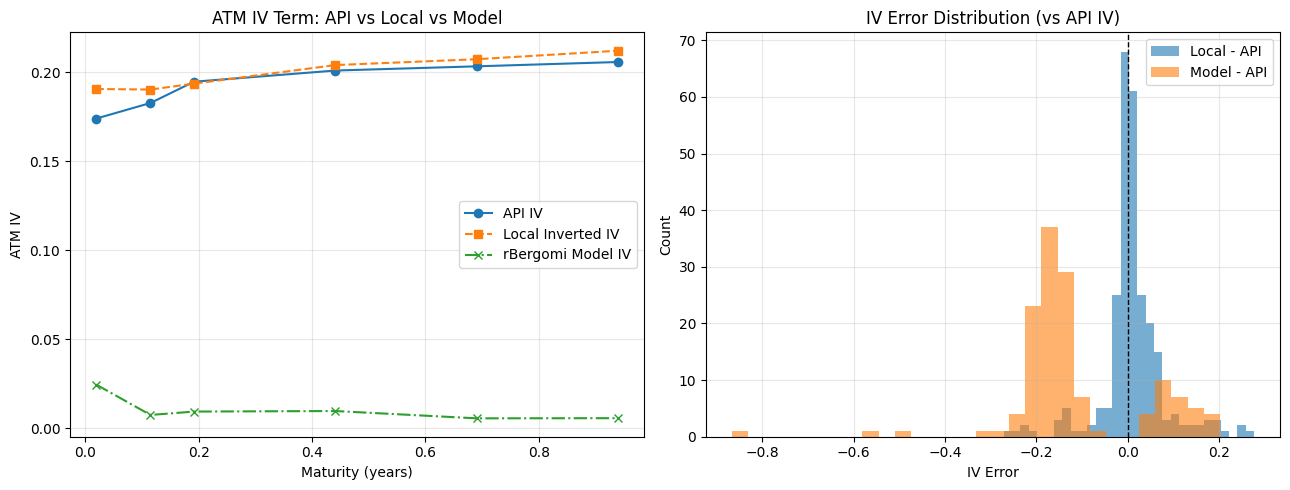

In [9]:
# 3) 三方比较：api_iv vs 本地反解 market_iv vs model_iv
compare_cols = [c for c in ['api_iv', 'market_iv', 'model_iv'] if c in best_df.columns]
df_cmp = best_df.copy()

if 'api_iv' in df_cmp.columns:
    df_cmp['err_local_vs_api'] = df_cmp['market_iv'] - df_cmp['api_iv']
    df_cmp['err_model_vs_api'] = df_cmp['model_iv'] - df_cmp['api_iv']

    summary = {
        'n_total': len(df_cmp),
        'api_iv_valid_ratio': df_cmp['api_iv'].notna().mean(),
        'local_market_iv_valid_ratio': df_cmp['market_iv'].notna().mean(),
        'model_iv_valid_ratio': df_cmp['model_iv'].notna().mean(),
        'rmse_local_vs_api': np.sqrt(np.nanmean(np.square(df_cmp['err_local_vs_api']))),
        'rmse_model_vs_api': np.sqrt(np.nanmean(np.square(df_cmp['err_model_vs_api']))),
    }
    display(pd.Series(summary))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 左图：按到期的ATM三方对比
    atm_rows = []
    for T, sub in df_cmp.groupby('maturity'):
        sub = sub.copy()
        F = sub['S0'].iloc[0] * np.exp((sub['r'].iloc[0] - sub['q'].iloc[0]) * T)
        sub['abs_mny'] = np.abs(np.log(sub['strike'] / F))
        atm = sub.nsmallest(max(2, len(sub)//6), 'abs_mny')
        atm_rows.append({
            'maturity': T,
            'api_atm_iv': atm['api_iv'].mean(),
            'local_atm_iv': atm['market_iv'].mean(),
            'model_atm_iv': atm['model_iv'].mean(),
        })
    df_atm_cmp = pd.DataFrame(atm_rows).sort_values('maturity')

    axes[0].plot(df_atm_cmp['maturity'], df_atm_cmp['api_atm_iv'], 'o-', label='API IV')
    axes[0].plot(df_atm_cmp['maturity'], df_atm_cmp['local_atm_iv'], 's--', label='Local Inverted IV')
    axes[0].plot(df_atm_cmp['maturity'], df_atm_cmp['model_atm_iv'], 'x-.', label='rBergomi Model IV')
    axes[0].set_title('ATM IV Term: API vs Local vs Model')
    axes[0].set_xlabel('Maturity (years)')
    axes[0].set_ylabel('ATM IV')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # 右图：误差分布（相对API）
    axes[1].hist(df_cmp['err_local_vs_api'].dropna(), bins=30, alpha=0.6, label='Local - API')
    axes[1].hist(df_cmp['err_model_vs_api'].dropna(), bins=30, alpha=0.6, label='Model - API')
    axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
    axes[1].set_title('IV Error Distribution (vs API IV)')
    axes[1].set_xlabel('IV Error')
    axes[1].set_ylabel('Count')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('当前 best_df 不包含 api_iv，请确认构建 cross 时 include_api_iv=True。')

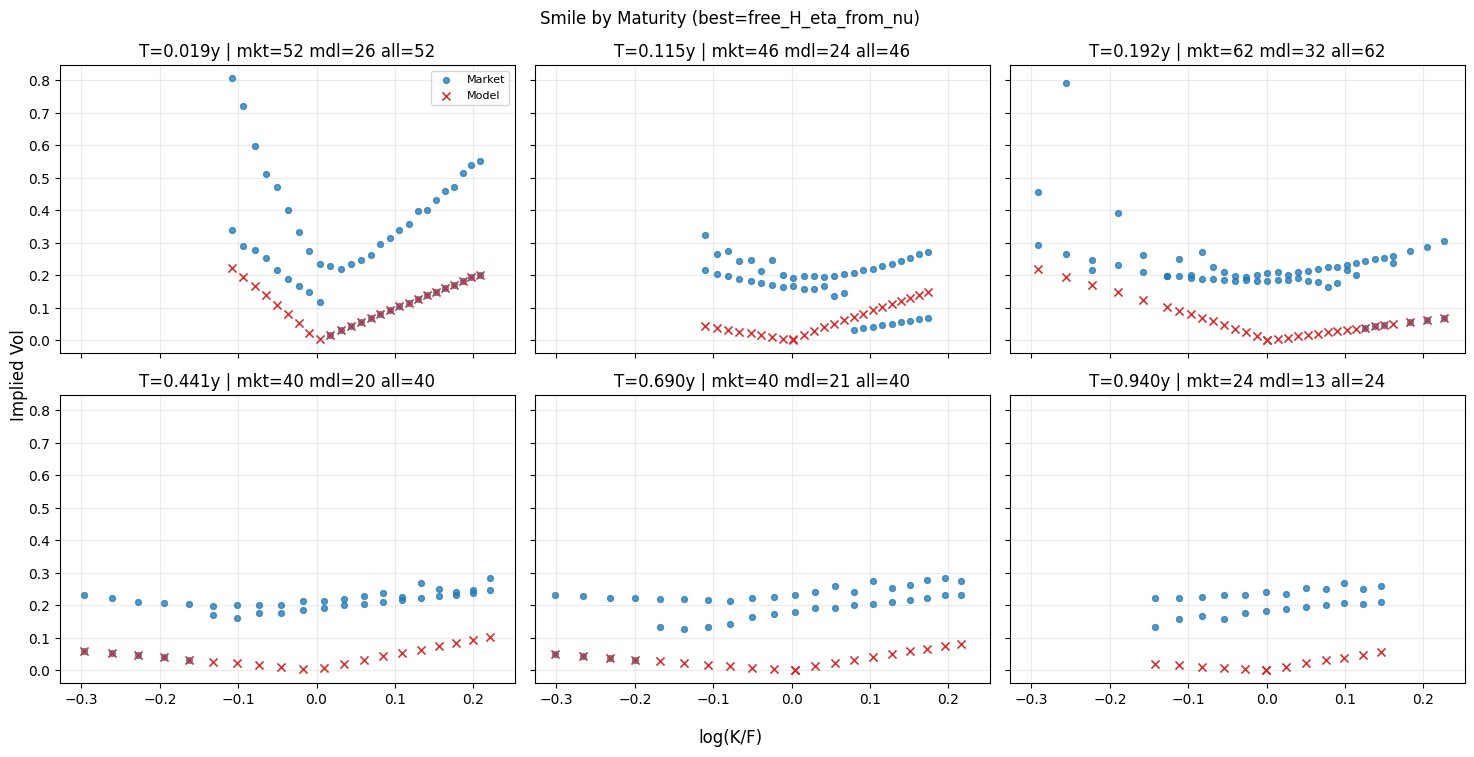

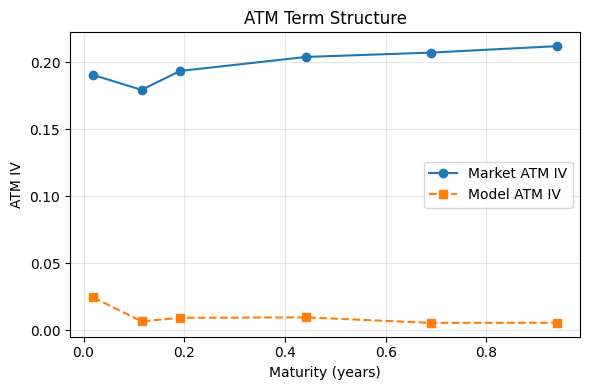

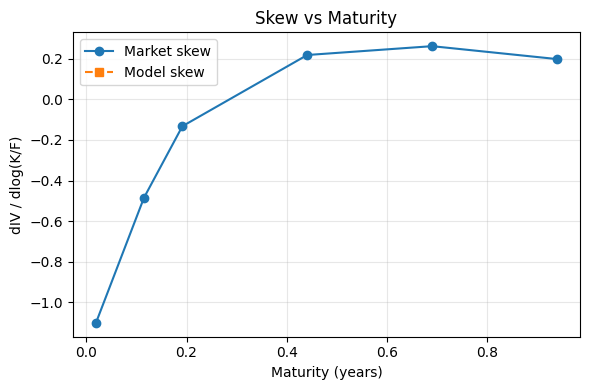

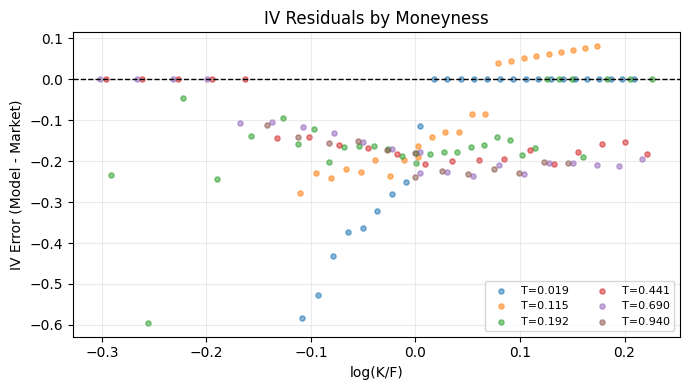

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_plot = best_df.copy()
df_plot['F'] = df_plot['S0'] * np.exp((df_plot['r'] - df_plot['q']) * df_plot['maturity'])
df_plot['log_mny'] = np.log(df_plot['strike'] / df_plot['F'])
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

# ---------- 图1：按到期分面 smile ----------
mats = sorted(df_plot['maturity'].unique())
n = len(mats)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, T in enumerate(mats):
    ax = axes[i]
    sub_all = df_plot[df_plot['maturity'] == T].copy()
    sub_mkt = sub_all.dropna(subset=['log_mny', 'market_iv']).sort_values('log_mny')
    sub_mdl = sub_all.dropna(subset=['log_mny', 'model_iv']).sort_values('log_mny')

    ax.scatter(
        sub_mkt['log_mny'], sub_mkt['market_iv'],
        s=18, alpha=0.75, marker='o', c='tab:blue',
        label='Market', zorder=2
    )
    ax.scatter(
        sub_mdl['log_mny'], sub_mdl['model_iv'],
        s=34, alpha=0.95, marker='x', c='tab:red',
        linewidths=1.2, label='Model', zorder=3
    )

    ax.set_title(
        f"T={T:.3f}y | mkt={len(sub_mkt)} mdl={len(sub_mdl)} all={len(sub_all)}"
    )
    ax.grid(alpha=0.25)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

axes[0].legend(loc='best', fontsize=8)
fig.supxlabel('log(K/F)')
fig.supylabel('Implied Vol')
fig.suptitle(f'Smile by Maturity (best={best_tag})')
plt.tight_layout()
plt.show()

# ---------- 图2：ATM term ----------
atm_rows = []
for T, sub in df_plot.groupby('maturity'):
    k = max(2, len(sub)//6)
    atm = sub.nsmallest(k, 'log_mny', keep='all', columns=None) if False else sub.iloc[(sub['log_mny'].abs()).argsort()[:k]]
    atm_rows.append({
        'maturity': T,
        'market_atm_iv': atm['market_iv'].mean(),
        'model_atm_iv': atm['model_iv'].mean(),
    })
df_atm = pd.DataFrame(atm_rows).sort_values('maturity')

plt.figure(figsize=(6,4))
plt.plot(df_atm['maturity'], df_atm['market_atm_iv'], 'o-', label='Market ATM IV')
plt.plot(df_atm['maturity'], df_atm['model_atm_iv'], 's--', label='Model ATM IV')
plt.xlabel('Maturity (years)')
plt.ylabel('ATM IV')
plt.title('ATM Term Structure')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 图3：skew term ----------
def local_skew(sub, width=0.15, iv_col='market_iv'):
    w = sub[np.abs(sub['log_mny']) <= width]
    if len(w) < 4:
        return np.nan
    x = w['log_mny'].values
    y = w[iv_col].values
    b = np.polyfit(x, y, 1)[0]  # slope
    return b

skew_rows = []
for T, sub in df_plot.groupby('maturity'):
    skew_rows.append({
        'maturity': T,
        'market_skew': local_skew(sub, width=0.15, iv_col='market_iv'),
        'model_skew': local_skew(sub, width=0.15, iv_col='model_iv'),
    })
df_skew = pd.DataFrame(skew_rows).sort_values('maturity')

plt.figure(figsize=(6,4))
plt.plot(df_skew['maturity'], df_skew['market_skew'], 'o-', label='Market skew')
plt.plot(df_skew['maturity'], df_skew['model_skew'], 's--', label='Model skew')
plt.xlabel('Maturity (years)')
plt.ylabel('dIV / dlog(K/F)')
plt.title('Skew vs Maturity')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 图4：残差散点 ----------
plt.figure(figsize=(7,4))
for T, sub in df_plot.groupby('maturity'):
    plt.scatter(sub['log_mny'], sub['iv_error'], s=14, alpha=0.55, label=f'T={T:.3f}')
plt.axhline(0.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('log(K/F)')
plt.ylabel('IV Error (Model - Market)')
plt.title('IV Residuals by Moneyness')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# 6) 与现有时间序列工作并行比较：P-ratio (RFSV vs AR/HAR)
START_IDX = 500
deltas = [1, 5, 20]

rfsv_pred = {}
ar5_pred = {}
ar10_pred = {}
har_pred = {}

for d in deltas:
    predictor = RFSVPredictor(H=H_hist, nu_sq=nu_sq_hist, delta=d, window_ratio=3.0)
    rfsv_pred[d] = predictor.predict_rolling(log_var, start_idx=START_IDX)
    ar5_pred[d] = predict_ar(log_var, delta=d, p=5, train_window=START_IDX)
    ar10_pred[d] = predict_ar(log_var, delta=d, p=10, train_window=START_IDX)
    har_pred[d] = predict_har(log_var, delta=d, train_window=START_IDX)

mean_log_var = float(np.mean(log_var[:START_IDX]))
rows = []
n = len(log_var)
for d in deltas:
    actual = log_var[START_IDX + d : n]
    rows.append({
        'delta': d,
        'P_AR5': compute_p_ratio(actual, ar5_pred[d], mean_log_var),
        'P_AR10': compute_p_ratio(actual, ar10_pred[d], mean_log_var),
        'P_HAR3': compute_p_ratio(actual, har_pred[d], mean_log_var),
        'P_RFSV': compute_p_ratio(actual, rfsv_pred[d], mean_log_var),
    })

df_ts_metrics = pd.DataFrame(rows)
df_ts_metrics

,delta,P_AR5,P_AR10,P_HAR3,P_RFSV
0,1,0.522131,0.522714,0.521847,0.605111
1,5,0.754069,0.758557,0.741843,0.820454
2,20,0.932508,0.937887,0.941406,1.156119


In [12]:
# 7) 联合汇总（期权截面 + 时间序列）
joint_summary = {
    'best_option_scenario': best_tag,
    'best_option_iv_rmse': float(df_option_metrics.iloc[0]['iv_rmse']),
    'best_option_atm_term_error': float(df_option_metrics.iloc[0]['atm_term_error']),
    'best_option_skew_error': float(df_option_metrics.iloc[0]['skew_error']),
    'avg_P_RFSV': float(df_ts_metrics['P_RFSV'].mean()),
    'avg_P_AR5': float(df_ts_metrics['P_AR5'].mean()),
    'avg_P_AR10': float(df_ts_metrics['P_AR10'].mean()),
    'avg_P_HAR3': float(df_ts_metrics['P_HAR3'].mean()),
}

pd.Series(joint_summary)

best_option_scenario          free_H_eta_from_nu
best_option_iv_rmse                     0.180685
best_option_atm_term_error              0.179495
best_option_skew_error                  0.887668
avg_P_RFSV                              0.860562
avg_P_AR5                               0.736236
avg_P_AR10                              0.739719
avg_P_HAR3                              0.735032
dtype: object